# Inflow score to infer CCC in single cell level

## Background

This notebook shows how to infer CCI in a single cell level, using spatial inflow function. 
<br>

</br>

## Load Packages

In [ ]:
!! pip install squidpy
!! pip install muon

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import plotnine as p9
import liana as li
import muon as mu
import anndata as ad
import matplotlib.pyplot as plt
import squidpy as sq
from liana.method._pipe_utils._common import _get_props
from liana.method.sp._utils import _add_complexes_to_var
from liana._logging import _logg
from liana.method._pipe_utils import prep_check_adata, assert_covered
from scipy.sparse import csr_matrix
#from liana.method.sp._inflow import inflow

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.


## Load and Prep Data

We will apply inflow score to colorectal cancer (CRC) whole-transcriptome spatial molecular imaging (WTx CosMx SMI) slide ([crowell2025tracing](https://doi.org/10.1101/2025.06.23.660674); [15574384](https://zenodo.org/records/15574384)).

In [ ]:
data_list = ['110', '120', '210', '221', '231', '232', '242']
data_name = '232'

In [ ]:
adata = sc.read(
    f"../data/crc_wt_cosmx/crc_{data_name}.h5ad",
    backup_url=f"https://zenodo.org/records/15574384/files/{data_name}.h5ad?download=1"
)

In [3]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## Basic QC

In [4]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)

## Calculate spatial connectivity matrix Wij

Change bandwidth value based on the spatial resolution of your data (e.g., spot size in Visium = 55 µm).

In [5]:
# Convert mm to um using global coordinates
adata.obs['CenterX_um'] = adata.obs['CenterX_global_mm'] * 1000
adata.obs['CenterY_um'] = adata.obs['CenterY_global_mm'] * 1000

In [ ]:
#Extract coords and save them in obsm["spatial"], li.ut.spatial_neighbors() and squidpy functions like sq.gr.spatial_autocorr() look for spatial coordinates in adata.obsm["spatial"] by default.
coords = adata.obs[['CenterX_um', 'CenterY_um']].to_numpy()
adata.obsm["spatial"] = coords

In [7]:
li.ut.spatial_neighbors(adata=adata, bandwidth=50)

In [11]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, n_jobs = 10,
                       show_progress_bar=True)

In [12]:
adata.uns['moranI']
#I: Moran’s I score for each gene
#pval: p-value (if permutation test is used)
#var_norm: Variance used to normalize Moran’s I (used internally for significance).
#pval_norm_fdr_bh: FDR-adjusted p-value (Benjamini-Hochberg correction) for multiple testing.

,I,pval_norm,var_norm,pval_norm_fdr_bh
FABP1,0.423416,0.000000,1.608876e-07,0.000000
COL1A1,0.381404,0.000000,1.608876e-07,0.000000
S100A6,0.372184,0.000000,1.608876e-07,0.000000
S100A4,0.363986,0.000000,1.608876e-07,0.000000
TMSB10,0.315749,0.000000,1.608876e-07,0.000000
...,...,...,...,...
LANCL3,-0.000463,0.128002,1.608876e-07,0.132698
CCBE1,-0.000499,0.110092,1.608876e-07,0.114708
FAM181B,-0.000569,0.080813,1.608876e-07,0.085181
CD163L1,-0.000574,0.078886,1.608876e-07,0.083270


## Visualize proximity

## Check spatially variable genes (SVGs)

In [13]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

1707

![SVGs_options](../_static/SVGs_plot.png)

### Option1: filter by SVGs 

Filtering your adata by SVGs (Spatially Variable Genes) means selecting only those LR interactions where BOTH the ligand and the receptor genes show spatial variability.
<br>

Keep in mind that applying this filter may reduce the number of detected LR pairs, possibly excluding biologically meaningful interactions where only one partner is spatially variable.
<br>

In this tutorial, we will use this filter for faster calculations
</br>

In [14]:
adata = adata[:, svgs]

### Option2: filter by SVGs and their pair

This option filters out ligand–receptor (LR) pairs only when neither the ligand nor the receptor is spatially variable.

In [ ]:
#retrive LR database
lr = li.rs.select_resource()
ligand_set = set(lr['ligand']) #1027
receptor_set = set(lr['receptor']) #1052

In [ ]:
svgs_df = adata.uns['moranI'][(adata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (adata.uns['moranI']['I'] > 0.01)]

In [ ]:
sorted_filtered = svgs_df.reset_index().rename(columns={'index': 'gene'})

# Create lookup dictionary for faster access
moran_dict = dict(zip(sorted_filtered['gene'], sorted_filtered['I']))

# Map Moran's I values to ligand and receptor
lr['ligand_moran_I'] = lr['ligand'].map(moran_dict)
lr['receptor_moran_I'] = lr['receptor'].map(moran_dict)

In [ ]:
lr_filtered = lr[~(lr['ligand_moran_I'].isna() & lr['receptor_moran_I'].isna())]

In [ ]:
genes_to_keep = np.unique(
    lr_filtered['ligand'].unique().tolist() + 
    lr_filtered['receptor'].unique().tolist()
)

In [ ]:
adata_filtered = adata[:, adata.var_names.isin(genes_to_keep)].copy()

## Compute inflow score 

In [15]:
lrdata = li.mt.inflow(adata,  
                                  groupby='ist', # cell type columns
                                  resource_name='cellchatdb',
                                  use_raw=False)
                                  
lrdata.shape

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


(129915, 784)

### Compute global score

In [14]:
li.mt.compute_global_score(lrdata, groupby='ist')

/g/stegle/aalsayah/repos/liana-py/liana/method/sc/_compute_global_score.py:89: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


In [15]:
lrdata.uns["global_score"].sort_values('lr_mean').tail()

,ligand,ligand_complex,receptor,receptor_complex,source,target,lr_mean
3380,MDK,MDK,NCL,NCL,epi4,epi4,0.219324
5075,COL1A1,COL1A1,SDC1,SDC1,fib2,fib2,0.229924
1700,MDK,MDK,NCL,NCL,epi2,epi2,0.236179
5044,COL1A1,COL1A1,CD44,CD44,fib2,fib2,0.255594
3517,COL1A1,COL1A1,SDC4,SDC4,fib2,epi4,0.287243


In [20]:
lrdata.uns["global_score"]["source"].unique()

array(['EC', 'epi1', 'epi2', 'epi3', 'epi4', 'fib1', 'fib2', 'mye1',
       'mye2', 'PC_IgA', 'PC_IgG', 'PC_IgM', 'SMC', 'TC'], dtype=object)

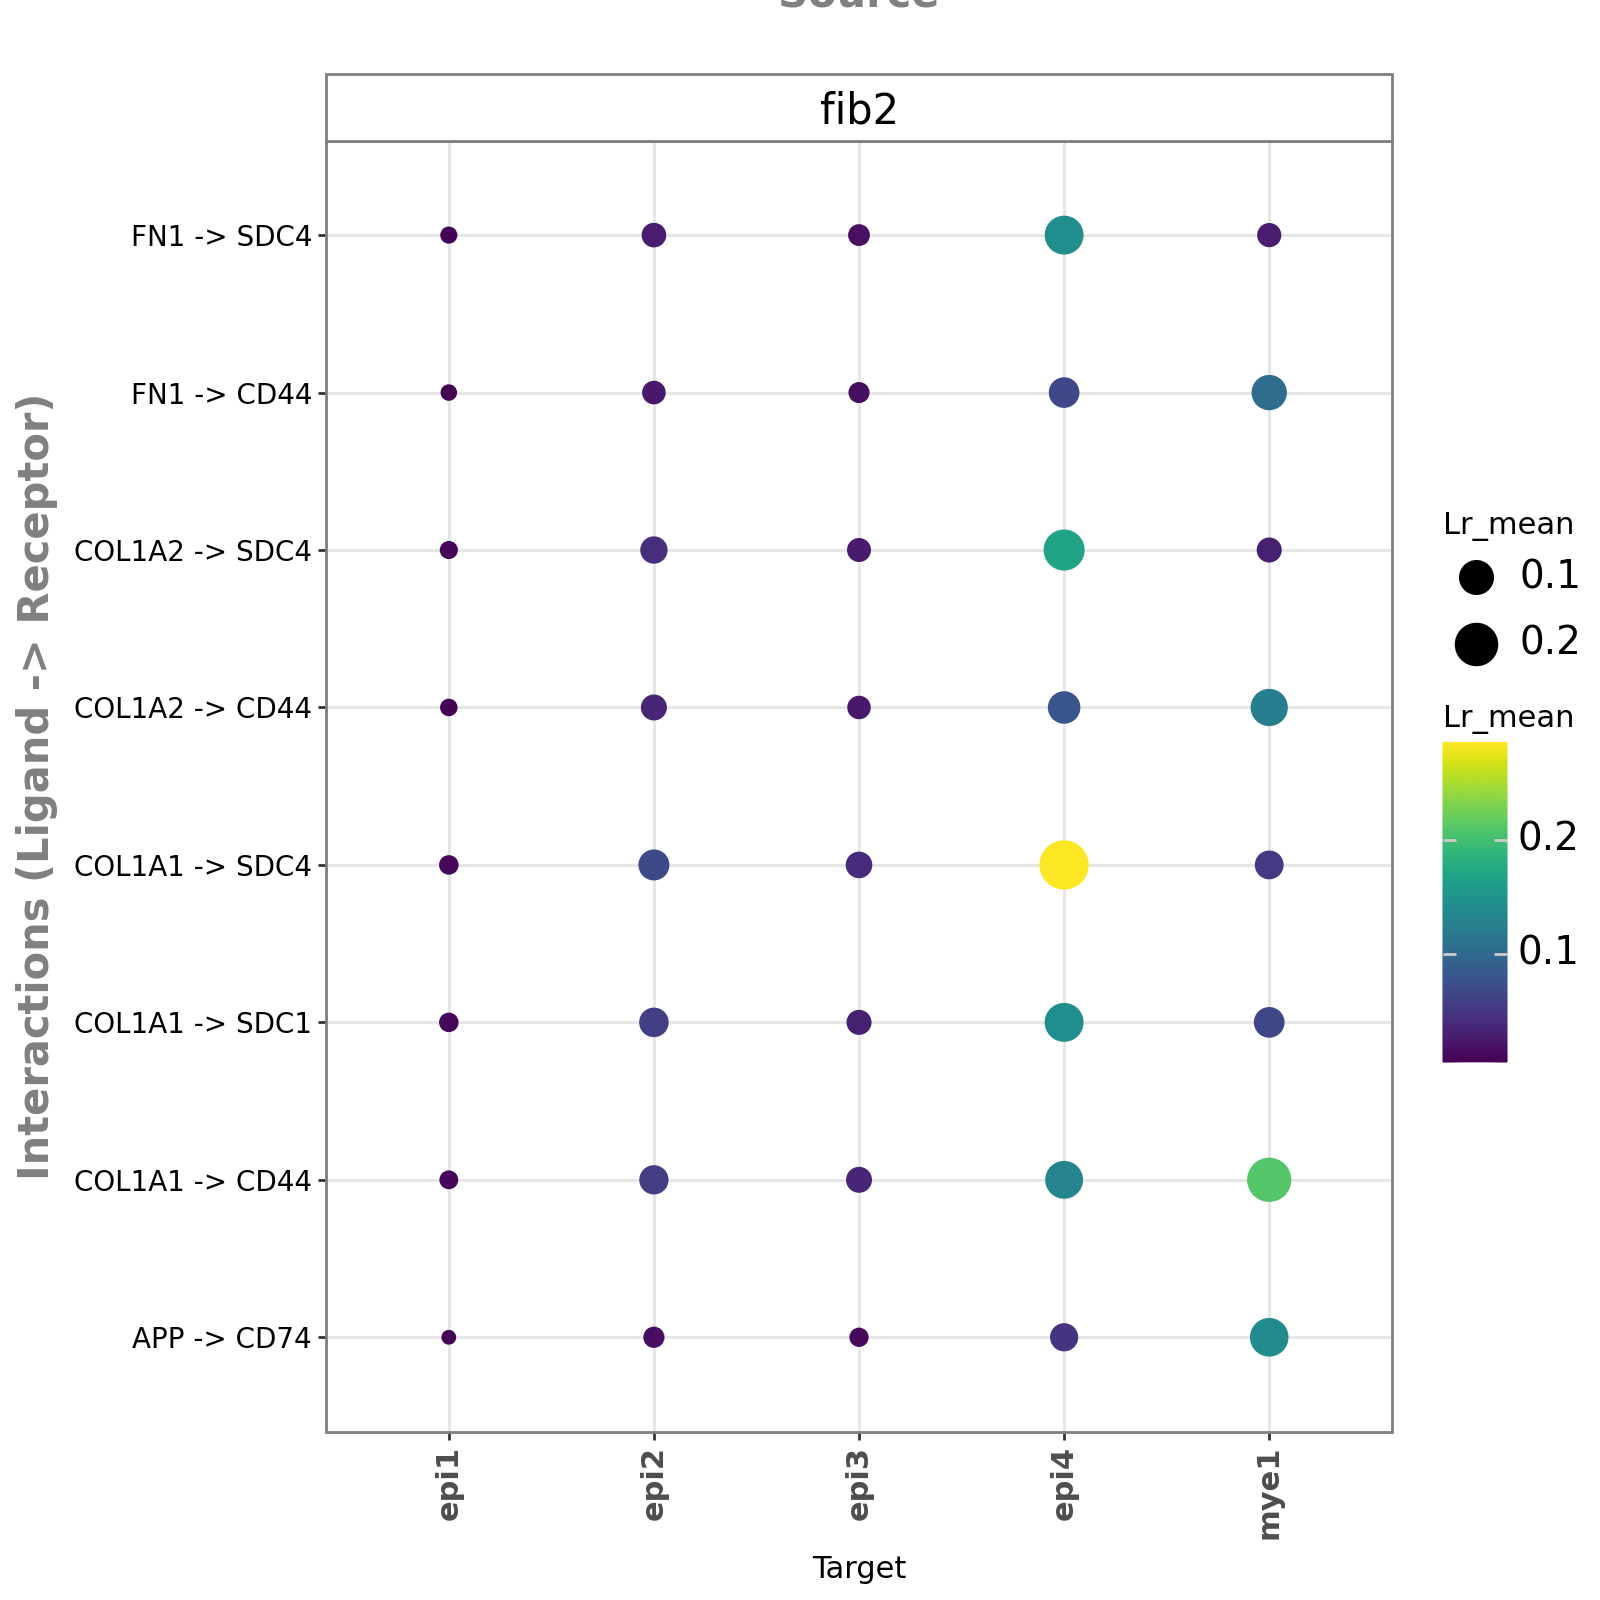

In [ ]:
li.pl.dotplot(adata = lrdata, 
              colour='lr_mean',
              size = "lr_mean",
              source_labels=['fib2'],
              target_labels=['epi1', "epi4", "epi3", "epi2", "mye1"],
              filter_fun=lambda x: x['lr_mean'] > 0.1,
              figure_size=(4, 3),
              uns_key='global_score' 
             )

## Optional: filter data to keep only spatially variable LR interaction

In [16]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

/g/stegle/aalsayah/Miniforge3/envs/liana_env/lib/python3.10/site-packages/squidpy/gr/_utils.py:203: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


In [17]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]

In [18]:
len(svis)

690

In [19]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
fib2^CEACAM1^CEACAM5,0.217356,0.0,1.608876e-07,0.0
mye2^CEACAM1^CEACAM5,0.226716,0.0,1.608876e-07,0.0
mye1^CEACAM1^CEACAM5,0.241905,0.0,1.608876e-07,0.0
epi3^MDK^NCL,0.261539,0.0,1.608876e-07,0.0
epi4^MDK^NCL,0.326481,0.0,1.608876e-07,0.0
epi2^MDK^NCL,0.340160,0.0,1.608876e-07,0.0
epi3^CEACAM1^CEACAM5,0.376875,0.0,1.608876e-07,0.0
epi1^CEACAM1^CEACAM5,0.382330,0.0,1.608876e-07,0.0
epi2^CEACAM1^CEACAM5,0.392461,0.0,1.608876e-07,0.0
epi4^CEACAM1^CEACAM5,0.464224,0.0,1.608876e-07,0.0


## Plot layout of chosen interactions

In [20]:
adata.layers['transformed'] = li.utils.zi_minmax(adata.X, cutoff=0.01)

/tmp/ipykernel_2743272/3987365680.py:1: ImplicitModificationWarning: Setting element `.layers['transformed']` of view, initializing view as actual.


/tmp/ipykernel_2743272/892736459.py:19: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743272/892736459.py:21: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743272/892736459.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743272/892736459.py:25: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743272/892736459.py:27: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_2743272/892736459.py:29: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


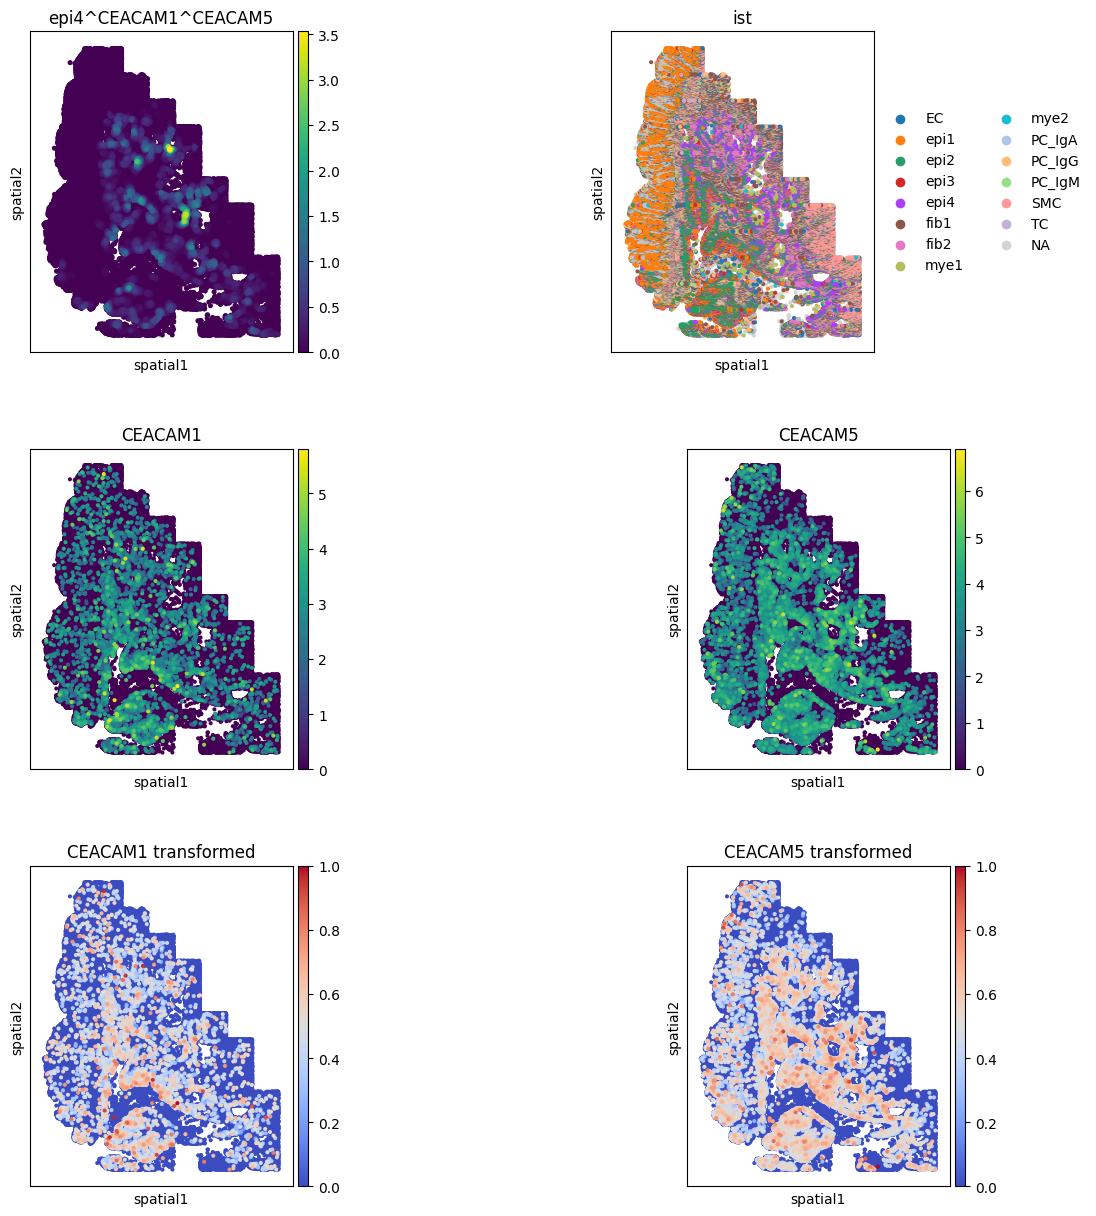

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

# Define your keys
key = 'epi4^CEACAM1^CEACAM5' 
xy_sep = '^'
groupby = 'ist'
keys = key.split(xy_sep)

if len(keys) < 2:
    raise ValueError("The 'key' variable should contain at least two elements separated by '&'.")

ligand = keys[1]
receptor = keys[2]

adata.obs['receptor'] = (adata[:, receptor].X > 0).toarray().flatten()

sc.pl.spatial(lrdata, color=[key], spot_size=100, ax=axes[0],show=False)
axes[0].set_title(f"{key}")
sc.pl.spatial(adata, color=[groupby], spot_size=80, ax=axes[1],show=False)
axes[1].set_title(f"{groupby}")
sc.pl.spatial(adata, color=[ligand], spot_size=80, ax=axes[2], show=False)
axes[2].set_title(f"{ligand}")
sc.pl.spatial(adata, color=[receptor], spot_size=80, ax=axes[3], show=False)
axes[3].set_title(f"{receptor}")
sc.pl.spatial(adata, color=[ligand], spot_size=80, ax=axes[4], show=False, layer='transformed', cmap='coolwarm')
axes[4].set_title(f"{ligand} transformed")
sc.pl.spatial(adata, color=[receptor], spot_size=80, ax=axes[5], show=False, layer='transformed', cmap='coolwarm')
axes[5].set_title(f"{receptor} transformed")
plt.show()